# **IST439 JULIA İLE İSTATİSTİKSEL PROGRAMLAMA PROJE ÖDEVİ**

**Selin Yüksektepe 20201101042**

*1.Giriş:Verinin Tanımı*

Kalp yetmezliği,dünya çapında 1 numaralı ölüm nedeni olan kardiyovasküler hastalıkların (CVD) neden olduğu yaygın bir olaydır.
Bu tür hastalıkları olan ya da yüksek risk altında olan kişiler için erken tespit büyük bir önem taşımaktadır. Bu veri setinin amacı, olası kalp hastalığını tahmin etmektir. Bunun için oluşturulmuş ve tahmin etmek için kullanılabilecek 11 değişken içermektedir. 11 değişken şu şekildedir:
1. Age: Hastanın yaşı

2. Sex: Hastanın cinsiyeti [F: Kadın, M: Erkek]

3. ChestPainType: Hastanın göğüs ağrı tipi [TA: Tipik Angina, ATA: Atipik Angina, NAP: Anginal Olmayan Ağrı, ASY: Asemptomatik]

4. RestingBP: Hastanın dinlenme kan basıncı [mm Hg]

5. Cholesterol: Hastanın serum kolesterolü [mm/dl]

6. FastingBS: Hastanın açlık kan şekeri [1: fastingBS>120 mg/dl ise, 0: aksi halde]

7. RestingECG: istirahat elektrokardiyogram sonuçları [Normal: Normal, ST: ST-T dalgası anormalliği (T dalgası inversiyonları ve/veya STelevasyonu veya > 0,05 mV depresyonu), LVH: Estes kriterlerine göre olası veya kesin sol ventriküler hipertrofiyi gösteren]

8. MaxHR: Ulaşılan maksimum kalp atış hızı [60 ile 202 arasındaki sayısal değer]

9. ExerciseAngina: Egzersize bağlı anjina [Y: Evet, N: Hayır]

10. Oldpeak: oldpeak = ST [Alçalmada ölçülen sayısal değer]

11. ST_Slope: Zirve egzersiz ST segmentinin eğimi [Up: yukarı eğimli, Flat: düz, Down: aşağı eğimli]

HeartDisease: [1: kalp hastalığı, 0: Normal]

Bu veri seti Kaggle'dan elde edilmiştir. Veri linki: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

- Daha kolay analiz edebilmek adına verimi RStudio ile 918 gözlemden 150 gözleme indirdim

# **Özet**
Bu proje, doğrusal regresyon modelleri, karar ağaçları, k-en yakın komşu algoritması ve kümeleme yöntemleri ile istatistiksel rapor oluşturmayı amaçlanması üzerine oluşturulmuştur.

In [1]:
using Pkg
Pkg.add("DataFrames")
Pkg.add("CSV")
Pkg.add("Plots")
Pkg.add("Lathe")
Pkg.add("GLM")
Pkg.add("StatsPlots")
Pkg.add("MLBase")
Pkg.add("Impute")
Pkg.add("Statistics")

    Updating registry at `~/.julia/registries/General`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes

In [2]:
using CSV
using DataFrames

In [3]:
data=CSV.read("heartdata2.csv",DataFrame)
print(data)

150×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease 
     │ Int64  String1  String3        Int64      Int64        Int64      String7     Int64  String1         Float64  String7   Int64        
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │    40  F        ASY                  150          392          0  Normal        130  N                   2.0  Flat                 1
   2 │    56  M        ASY                  130          283          1  LVH           103  Y                   1.6  Down                 1
   3 │    67  M        ASY                  160          286          0  LVH           108  Y                   1.5  Flat                 1
   4 │    50  M        ASY                  144          349          0  LVH           120  Y                   1.0  Up                   1


In [4]:
names(data)

12-element Vector{String}:
 "Age"
 "Sex"
 "ChestPainType"
 "RestingBP"
 "Cholesterol"
 "FastingBS"
 "RestingECG"
 "MaxHR"
 "ExerciseAngina"
 "Oldpeak"
 "ST_Slope"
 "HeartDisease"

In [5]:
size(data)

(150, 12)

Veride "cholesterol" değişkeninde "0" değerli gözlemler bulunduğu için, çalışmayı etkilememesi adına "0" gözlemleri çıkartmak ile başlıyorum.

In [6]:
newdata =data[data.Cholesterol .!= 0, :]
print(newdata)

126×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease 
     │ Int64  String1  String3        Int64      Int64        Int64      String7     Int64  String1         Float64  String7   Int64        
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │    40  F        ASY                  150          392          0  Normal        130  N                   2.0  Flat                 1
   2 │    56  M        ASY                  130          283          1  LVH           103  Y                   1.6  Down                 1
   3 │    67  M        ASY                  160          286          0  LVH           108  Y                   1.5  Flat                 1
   4 │    50  M        ASY                  144          349          0  LVH           120  Y                   1.0  Up                   1


In [7]:
size(newdata)

(126, 12)

# *Modellerin Tanımlanması*

In [8]:
using Pkg
using Plots
using StatsPlots 
Pkg.add("Distributions")
using Distributions
Pkg.add("RDatasets")
using RDatasets, StatsPlots
using StatsBase 
using Statistics

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


In [9]:
describe(newdata,:nmissing)

,variable,nmissing
,Symbol,Int64
1,Age,0
2,Sex,0
3,ChestPainType,0
4,RestingBP,0
5,Cholesterol,0
6,FastingBS,0
7,RestingECG,0
8,MaxHR,0
9,ExerciseAngina,0


In [10]:
# Betimsel İstatistik
bi=describe(newdata,:all) 
println(bi)

12×13 DataFrame
 Row │ variable        mean      std       min   q25     median  q75     max  nunique  nmissing  first   last    eltype   
     │ Symbol          Union…    Union…    Any   Union…  Union…  Union…  Any  Union…   Int64     Any     Any     DataType 
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Age             52.3492   10.381    28    45.0    53.0    58.75   75                   0  40      56      Int64
   2 │ Sex                                 F                             M    2               0  F       M       String1
   3 │ ChestPainType                       ASY                           TA   4               0  ASY     ASY     String3
   4 │ RestingBP       131.897   17.8325   100   120.0   130.0   140.0   200                  0  150     155     Int64
   5 │ Cholesterol     247.778   57.1376   132   205.25  244.0   276.0   564                  0  392     342     Int64
   6 │ FastingBS

In [11]:
mean(newdata.Age)
median(newdata.Age)
var_age=var(newdata.Age)
describe(newdata.Age) 
println("Yaş değişkenin varyansı $var_age")

Summary Stats:
Length:         126
Missing Count:  0
Mean:           52.349206
Minimum:        28.000000
1st Quartile:   45.000000
Median:         53.000000
3rd Quartile:   58.750000
Maximum:        75.000000
Type:           Int64
Yaş değişkenin varyansı 107.76507936507933


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


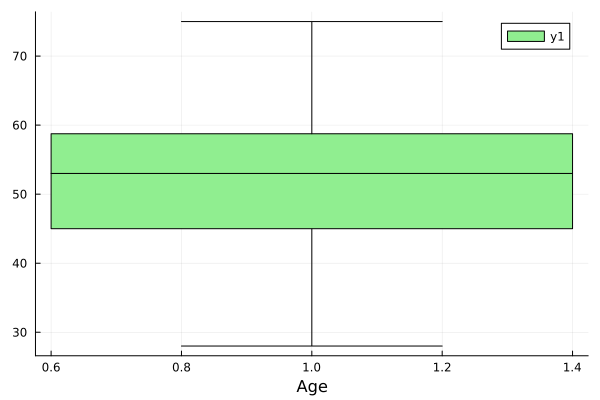

In [12]:
Pkg.add("StatsPlots")
using StatsPlots 
boxplot(newdata.Age,xlabel="Age",fillcolor=:lightgreen)

In [13]:
mean(newdata.Cholesterol)
median(newdata.Cholesterol)
var_chol=var(newdata.Cholesterol)
describe(newdata.Cholesterol) 
println("Kolesterol değişkenin varyansı $var_chol")

Summary Stats:
Length:         126
Missing Count:  0
Mean:           247.777778
Minimum:        132.000000
1st Quartile:   205.250000
Median:         244.000000
3rd Quartile:   276.000000
Maximum:        564.000000
Type:           Int64
Kolesterol değişkenin varyansı 3264.7022222222217


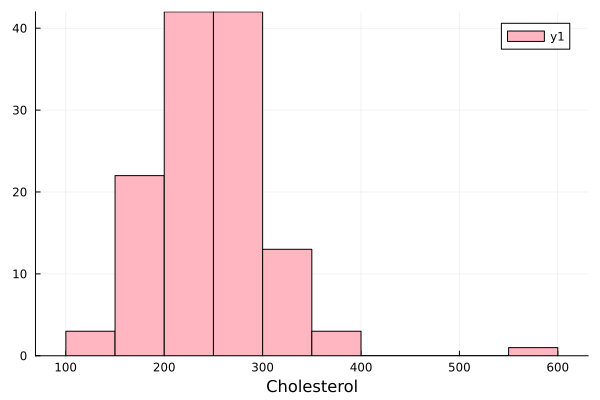

In [14]:
using StatsPlots 
histogram(newdata.Cholesterol,xlabel="Cholesterol",fillcolor=:lightpink)

In [15]:
using StatsBase , Statistics
Mode_sex= StatsBase.mode(newdata.Sex)

"M"

In [16]:
if Mode_sex == "M"
    println("Hastalarda en çok tekrar eden cinsiyet erkek")
else println("Hastalarda en çok tekrar eden cinsiyet kadın")
end

Hastalarda en çok tekrar eden cinsiyet erkek


In [17]:
Mode_ChestPainType=StatsBase.mode(newdata.ChestPainType)
if Mode_ChestPainType== "TA"
    println("Hastalarda en çok tekrar eden göğüs ağrı tipi Tipik Angina")
elseif Mode_ChestPainType== "ATA"
    println("Hastalarda en çok tekrar eden göğüs ağrı tipi Atipik Angina")
elseif Mode_ChestPainType== "NAP"
    println("Hastalarda en çok tekrar eden göğüs ağrı tipi Anginal Olmayan Ağrı")
else println("Hastalarda en çok tekrar eden göğüs ağrı tipi Asemptomatik")
end


Hastalarda en çok tekrar eden göğüs ağrı tipi Asemptomatik


In [18]:
using Statistics
cor_chol_age=cor(newdata.Cholesterol,newdata.Age)
println("Kolesterol ile Yaş arasındaki korelasyon katsayısı $cor_chol_age çıkmıştır")

if cor_chol_age > 0.05
    println("p>0.05 olduğu için H0 reddedilemez. Yani kolesterol ve yaş arasında anlamlı bir ilişki yoktur")
else println("H0 reddedilir. Yani kolesterol ve yaş arasında anlamlı bir ilişki vardır")
end

Kolesterol ile Yaş arasındaki korelasyon katsayısı 0.07920867358769333 çıkmıştır
p>0.05 olduğu için H0 reddedilemez. Yani kolesterol ve yaş arasında anlamlı bir ilişki yoktur


In [19]:
using Statistics
cor_chol_age=cor(newdata.Cholesterol,newdata.Age)
println("Kolesterol ile Yaş arasındaki korelasyon katsayısı $cor_chol_age çıkmıştır")

if cor_chol_age > 0.05
    println("p>0.05 olduğu için H0 reddedilemez. Yani kolesterol ve yaş arasında anlamlı bir ilişki yoktur")
else println("H0 reddedilir. Yani kolesterol ve yaş arasında anlamlı bir ilişki vardır")
end

Kolesterol ile Yaş arasındaki korelasyon katsayısı 0.07920867358769333 çıkmıştır
p>0.05 olduğu için H0 reddedilemez. Yani kolesterol ve yaş arasında anlamlı bir ilişki yoktur


In [20]:
using Statistics
cor(newdata.Age,newdata.Cholesterol)

0.07920867358769333

# **Doğrusal Regresyon**

In [21]:
using Pkg
Pkg.add("DataFrames")
Pkg.add("CSV")
Pkg.add("Plots")
Pkg.add("Lathe")
Pkg.add("GLM")
Pkg.add("StatsPlots")
Pkg.add("MLBase")
Pkg.add("Statistics")

using DataFrames
using CSV
using Plots
using Lathe
using GLM
using StatsPlots
using MLBase
using Statistics

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Chan

In [22]:
describe(newdata)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Age,52.3492,28,53.0,75,0,Int64
2,Sex,,F,,M,0,String1
3,ChestPainType,,ASY,,TA,0,String3
4,RestingBP,131.897,100,130.0,200,0,Int64
5,Cholesterol,247.778,132,244.0,564,0,Int64
6,FastingBS,0.15873,0,0.0,1,0,Int64
7,RestingECG,,LVH,,ST,0,String7
8,MaxHR,140.968,87,140.0,202,0,Int64
9,ExerciseAngina,,N,,Y,0,String1


*Doğrusal İlişkinin Varlığı*

*Doğrusal İlişkinin Varlığı*

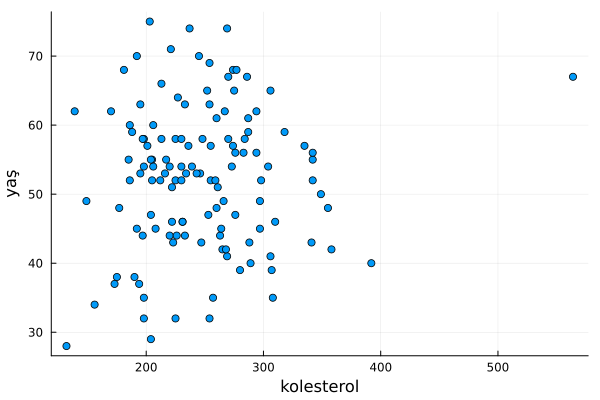

In [23]:
scatter(newdata.Cholesterol, newdata.Age, xlabel="kolesterol", ylabel="yaş",legend=false)

*Dağılım Analizi*

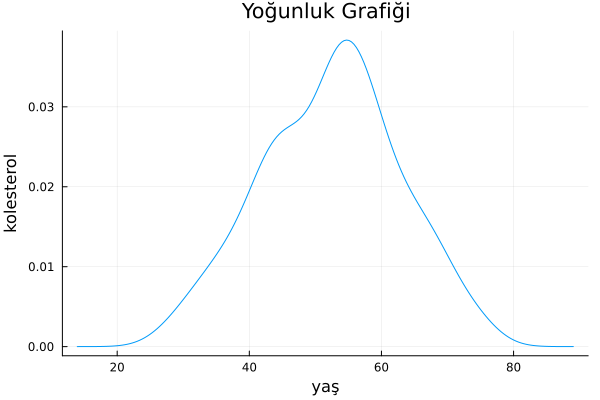

In [24]:
density(newdata.Age, title="Yoğunluk Grafiği", ylabel="kolesterol", xlabel="yaş",legend=false)

**Train Test**

In [25]:
using Lathe.preprocess: TrainTestSplit
train,test=TrainTestSplit(newdata,.75)

(92×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  Resti ⋯
     │ Int64  String1  String3        Int64      Int64        Int64      Strin ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    40  F        ASY                  150          392          0  Norma ⋯
   2 │    56  M        ASY                  130          283          1  LVH
   3 │    53  F        ASY                  138          234          0  LVH
   4 │    62  M        ASY                  120          267          0  Norma
   5 │    62  M        TA                   135          139          0  ST    ⋯
   6 │    52  M        TA                   118          186          0  LVH
   7 │    69  M        NAP                  140          254          0  LVH
   8 │    35  M        ATA                  110          257          0  Norma
   9 │    51  M        ASY                  140          261          0  LVH   ⋯
  10 │    39  M        ASY     

In [26]:
using GLM
fm=@formula(Cholesterol~Age)
linreg=lm(fm,newdata)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Cholesterol ~ 1 + Age

Coefficients:
──────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error     t  Pr(>|t|)   Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)  224.955      26.2921    8.56    <1e-13  172.916     276.995
Age            0.435969    0.492726  0.88    0.3780   -0.539273    1.41121
──────────────────────────────────────────────────────────────────────────

In [27]:
r2(linreg)

0.006274013971521608

In [28]:
test_pred=predict(linreg,test)

34-element Vector{Union{Missing, Float64}}:
 254.16506804925478
 246.75359688917695
 247.6255346727155
 244.13778353856122
 254.16506804925478
 247.6255346727155
 251.54925469863906
 244.13778353856122
 249.80537913156192
 254.60103694102406
 245.44569021386909
 252.85716137394692
 248.49747245625406
   ⋮
 248.49747245625406
 238.9061568373298
 243.26584575502264
 238.9061568373298
 245.00972132209978
 255.47297472456265
 250.24134802333123
 237.16228127025266
 246.31762799740764
 248.93344134802336
 246.31762799740764
 249.80537913156192

In [29]:
train_pred=predict(linreg,train)

92-element Vector{Union{Missing, Float64}}:
 242.39390797148408
 249.36941023979264
 248.06150356448478
 251.98522359040837
 251.98522359040837
 247.6255346727155
 255.03700583279337
 240.21406351263764
 247.18956578094623
 241.95793907971478
 252.42119248217764
 238.9061568373298
 250.24134802333123
   ⋮
 254.60103694102406
 257.2168502916398
 245.88165910563836
 245.44569021386909
 247.6255346727155
 248.93344134802336
 250.24134802333123
 253.29313026571623
 248.49747245625406
 255.47297472456265
 243.70181464679195
 249.36941023979264

In [30]:
perf_test=DataFrame(y_original=test[!,:Cholesterol],y_pred=test_pred)

,y_original,y_pred
,Int64,Float64?
1,286,254.165
2,349,246.754
3,298,247.626
4,263,244.138
5,270,254.165
6,205,247.626
7,260,251.549
8,220,244.138
9,335,249.805


In [31]:
perf_test.hata=perf_test[!,:y_original]-perf_test[!,:y_pred]

34-element Vector{Float64}:
   31.834931950745215
  102.24640311082305
   50.3744653272845
   18.862216461438777
   15.834931950745215
  -42.6255346727155
    8.45074530136094
  -24.137783538561223
   85.19462086843808
   19.398963058975937
   30.554309786130915
  -25.857161373946923
  -42.49747245625406
    ⋮
  -28.49747245625406
  -40.9061568373298
   21.73415424497736
   15.093843162670197
   64.99027867790022
  -63.47297472456265
  -53.24134802333123
 -105.16228127025266
  -97.31762799740764
   93.06655865197664
   19.68237200259236
    5.194620868438079

In [32]:
perf_test.hata_kare=perf_test.hata.*perf_test.hata

34-element Vector{Float64}:
  1013.4628923085785
 10454.326949100927
  2537.586757009788
   355.78320983817196
   250.74506988473166
  1816.9362061348716
    71.41509614847399
   582.6325941544371
  7258.123424916905
   376.319767763513
   933.5658465068555
   668.5927943183327
  1806.0351651700723
     ⋮
   812.1059363949587
  1673.3136672002238
   472.3734607444675
   227.82410141928585
  4223.736322631132
  4028.8185203849685
  2834.641139341476
 11059.105401963734
  9470.72071904182
  8661.384339321807
   387.39576764843156
    26.984085966812383

In [33]:
perf_test

,y_original,y_pred,hata,hata_kare
,Int64,Float64?,Float64,Float64
1,286,254.165,31.8349,1013.46
2,349,246.754,102.246,10454.3
3,298,247.626,50.3745,2537.59
4,263,244.138,18.8622,355.783
5,270,254.165,15.8349,250.745
6,205,247.626,-42.6255,1816.94
7,260,251.549,8.45075,71.4151
8,220,244.138,-24.1378,582.633
9,335,249.805,85.1946,7258.12


In [34]:
perf_train=DataFrame(y_original=train[!,:Cholesterol],y_pred=train_pred)

,y_original,y_pred
,Int64,Float64?
1,392,242.394
2,283,249.369
3,234,248.062
4,267,251.985
5,139,251.985
6,186,247.626
7,254,255.037
8,257,240.214
9,261,247.19


In [35]:
perf_train.hata=perf_train[!,:y_original]-perf_train[!,:y_pred]

92-element Vector{Float64}:
  149.60609202851592
   33.63058976020736
  -14.06150356448478
   15.014776409591633
 -112.98522359040837
  -61.6255346727155
   -1.037005832793369
   16.785936487362363
   13.810434219053775
   65.04206092028522
  -19.421192482177645
  -13.906156837329803
   19.758651976668773
    ⋮
  -73.60103694102406
   11.783149708360213
  -68.88165910563836
  -41.445690213869085
  -17.625534672715503
  -31.933441348023365
  -20.241348023331227
   21.70686973428377
   24.50252754374594
  -10.472974724562647
  -20.701814646791945
   92.63058976020736

In [36]:
perf_train.hata_kare=perf_train.hata.*perf_train.hata

92-element Vector{Float64}:
 22381.982772044776
  1131.016567619364
   197.7258824940182
   225.4435106300294
 12765.660749774572
  3797.7065236980607
     1.075381097247469
   281.7676637577631
   190.72809331881146
  4230.469688758094
   377.18271742979346
   193.38119798441443
   390.4043279351168
     ⋮
  5417.1126387939885
   138.84261704962938
  4744.682961145372
  1717.7452373040037
   310.6594724990964
  1019.7446763276483
   409.71216980161495
   471.1881936611648
   600.3738560320285
   109.68319958132805
   428.5651296701295
  8580.426159323832

*Performans Ölçümü*
- MAE (ortalama mutlak hata)
- MAPE (ortalama mutlak yüzde hata)
- RMSE (kök ortalama kare hatası)
- MSE (hata kareleri ortalaması)

In [37]:
function mape(perf_newdata)
    mape=mean(abs.(perf_newdata.hata./perf_newdata.y_original))
    return mape
end

mape (generic function with 1 method)

In [38]:
mape(perf_test)

0.19311319552389958

In [39]:
function rmse(perf_newdata)
    rmse=sqrt(mean(perf_newdata.hata.*perf_newdata.hata))
    return rmse
end

rmse (generic function with 1 method)

*Hata Analizi*

In [40]:
println("ortalama mutlak test hatası: ",mean(abs.(perf_test.hata)))
println("ortalama mutlak test hatası:",mape(perf_test))
println("kök ortalama kare test hatası:",rmse(perf_test))
println("hata kareleri ortalaması test hatası:",mean(perf_test.hata_kare))

ortalama mutlak test hatası: 43.05129045785521
ortalama mutlak test hatası:0.19311319552389958
kök ortalama kare test hatası:51.326051797437266
hata kareleri ortalaması test hatası:2634.363593113213


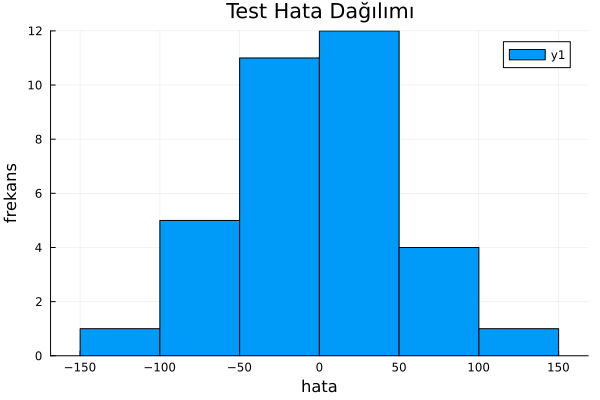

In [41]:
histogram(perf_test.hata,title="Test Hata Dağılımı",ylabel="frekans",xlabel="hata",legend=true)

In [42]:
println("ortalama mutlak train hatası:",mean(abs.(perf_train.hata)))
println("ortalama mutlak yüzde train hatası:",mape(perf_train))
println("kök ortalama kare train hatası:",rmse(perf_train))
println("hata kareleri ortalaması train hatası:",mean(perf_train.hata_kare))

ortalama mutlak train hatası:42.60537067823833
ortalama mutlak yüzde train hatası:0.17359914298080922
kök ortalama kare train hatası:58.60322249565695
hata kareleri ortalaması train hatası:3434.3376868754726


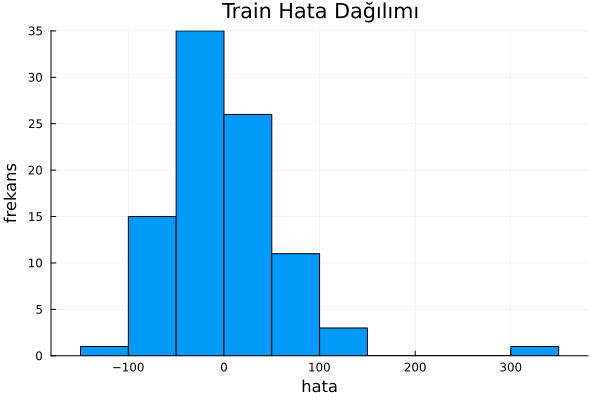

In [43]:
histogram(perf_train.hata,title="Train Hata Dağılımı",ylabel="frekans",xlabel="hata",legend=false)

In [44]:
train

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR
,Int64,String1,String3,Int64,Int64,Int64,String7,Int64
1,40,F,ASY,150,392,0,Normal,130
2,56,M,ASY,130,283,1,LVH,103
3,53,F,ASY,138,234,0,LVH,160
4,62,M,ASY,120,267,0,Normal,99
5,62,M,TA,135,139,0,ST,137
6,52,M,TA,118,186,0,LVH,190
7,69,M,NAP,140,254,0,LVH,146
8,35,M,ATA,110,257,0,Normal,140
9,51,M,ASY,140,261,0,LVH,186


In [45]:
function corss_validation(newdata,k,fm)
    a=collect(Kfold(size(newdata)[1],k))
    hata=[]
    for i in 1:k
        row=a[i]
        temp_train=newdata[row,:]
        temp_test=newdata[setdiff(1:end,row),:]
        linreg=lm(fm,temp_train)
        perf_test=DataFrame(y_original=temp_test[!,:Cholesterol],y_pred=predict(linreg,temp_test))
        perf_test.hata=perf_test[!,:y_original]-perf_test[!,:y_pred]
        println("$i. set için ortalama hata: ",mean(abs.(perf_test.hata)))
        hata=push!(hata,mean(abs.(perf_test.hata)))
    end
    println("Ortalama Hata: ",mean(hata))
end

corss_validation (generic function with 1 method)

In [46]:
size(newdata)

(126, 12)

In [47]:
a=collect(Kfold(size(newdata)[1],10))
a[5]

113-element Vector{Int64}:
   1
   2
   3
   4
   5
   6
   7
   8
   9
  10
  11
  12
  14
   ⋮
 114
 115
 116
 117
 118
 119
 120
 121
 122
 123
 124
 125

In [48]:
fm

FormulaTerm
Response:
  Cholesterol(unknown)
Predictors:
  Age(unknown)

In [49]:
using Pkg
Pkg.add("MLJ")
Pkg.add("ScikitLearn")

using MLJ
using ScikitLearn

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
[ Info: Precompiling ScikitLearn [3646fa90-6ef7-5e7e-9f22-8aca16db6324]
ERROR: LoadError: LoadError: could not load library "/Users/selinyuksektepe/.julia/conda/3/aarch64/lib/libpython3.12.dylib"
dlopen(/Users/selinyuksektepe/.julia/conda/3/aarch64/lib/libpython3.12.dylib, 0x0009): tried: '/Users/selinyuksektepe/.julia/conda/3/aarch64/lib/libpython3.12.dylib' (mach-o file, but is an incompatible architecture (have 'arm64', need 'x86_64')), '/System/Volumes/Preboot/Cryptexes/OS/Users/selinyuksektepe/.julia/conda/3/aarch64/lib/libpython3.12.dylib' (no such file), '/Users/selinyuksektepe/.julia/conda/3/aarch64/lib/libpython3.12.dylib' (mach-o file, but is an incompatible architecture (have 'arm

LoadError: Failed to precompile ScikitLearn [3646fa90-6ef7-5e7e-9f22-8aca16db6324] to /Users/selinyuksektepe/.julia/compiled/v1.6/ScikitLearn/jl_cQsarG.

In [50]:
cross_validation(newdata,10,fm)

LoadError: UndefVarError: cross_validation not defined

# Sonuç

- **MAE:** modelin tahminlerinin gerçek değerden ortalma uzaklığını hesaplar.
  modelin MAE değeri: 43.05
- **MAPE:** tahmin hatalarını yüzdesel hesaplar. düşük MAPE değeri iyi performans demektir.
  modelin MAPE değeri: 0.19
- **RMSE:** modelin tahminlerinin gerçek değerlerden ortalama uzaklığını ve bu uzaklığın karelerinin ortalama karekökünü gösterir.düşük RMSE değeri iyi performan anlamına gelmektedir.
  modelim RMSE değeri: 51.32
- **MSE:** modelin tahmin hatalarının karelerini ölçer. ne kadar düşük değer alırsa, modelin tahminleri o kadar iyi performans gösterdiği kabul edilir.
   modelim MSE değeri: 2634.36

  sonuç olarak modelin performansının iyi olduğu kabul edilebilir.

**Çoklu Doğrusal Regresyon**

In [51]:
using GLM
fm1=@formula(Cholesterol ~ Age + RestingBP + MaxHR)
linreg1=lm(fm1,train)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Cholesterol ~ 1 + Age + RestingBP + MaxHR

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error      t  Pr(>|t|)   Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)  273.657       73.9091     3.70    0.0004  126.778     420.535
Age            0.124524     0.67864    0.18    0.8548   -1.22413     1.47318
RestingBP      0.0382934    0.368815   0.10    0.9175   -0.69465     0.771236
MaxHR         -0.255924     0.271113  -0.94    0.3478   -0.794705    0.282857
─────────────────────────────────────────────────────────────────────────────

In [52]:
r2(linreg)

0.006274013971521608

In [53]:
test_pred1=predict(linreg1,test)
train_pred1=predict(linreg1,train)

92-element Vector{Union{Missing, Float64}}:
 251.11151110262588
 259.24796768884386
 244.5930875065882
 260.6358723177524
 251.48516919570608
 236.02498275787346
 250.24498911016838
 246.39791907066657
 237.76660819089437
 247.66188198403435
 248.6656176228639
 234.7637010745575
 258.2154926102705
   ⋮
 252.897333465111
 256.4998355639684
 246.35227284470676
 247.20102090885808
 243.47293597298315
 258.40419175537227
 247.46859769794614
 257.29759714028364
 246.26718779675394
 251.74997827149997
 246.49932875043004
 248.17688425003402

In [54]:
perf_test1=DataFrame(y_original=test[!,:Cholesterol],y_pred=test_pred1)

,y_original,y_pred
,Int64,Float64?
1,286,260.487
2,349,254.686
3,298,256.958
4,263,239.456
5,270,255.447
6,205,237.943
7,260,250.018
8,220,240.224
9,335,248.37


In [55]:
perf_test1.hata=perf_test1[!,:y_original]-perf_test1[!,:y_pred]

34-element Vector{Float64}:
   25.513087498905463
   94.31377261292803
   41.04159426148311
   23.5439171727312
   14.5530724747357
  -32.94345916370236
    9.981526593946313
  -20.22385417178728
   86.6303271350406
   23.37149501863442
   23.120136617013486
  -21.467856877258896
  -50.95343360783721
    ⋮
  -29.75950026329903
  -41.43478606477862
   13.430132746034246
   11.240108686575866
   57.730344498540774
  -63.869018416094974
  -55.33114954656324
 -102.77554924685131
 -103.03053316442998
   98.92316767263202
   25.02651654319706
   -7.953520588941558

In [56]:
perf_test1.hata_kare=perf_test1.hata.*perf_test1.hata

34-element Vector{Float64}:
   650.9176337268062
  8895.087704483094
  1684.4124595242035
   554.3160358364271
   211.79191845490988
  1085.271501670525
    99.63087314565749
   409.0042775617178
  7504.813579524152
   546.2267794060535
   534.5407171893678
   460.8688789024721
  2596.2523964282746
     ⋮
   885.6278559212951
  1716.8414962339725
   180.36846557610136
   126.34004328603824
  3332.792675920197
  4079.251513435479
  3061.5361101441454
 10562.813522991959
 10615.290764146706
  9785.793102387668
   626.3265302869162
    63.25848975871727

In [57]:
perf_test1

,y_original,y_pred,hata,hata_kare
,Int64,Float64?,Float64,Float64
1,286,260.487,25.5131,650.918
2,349,254.686,94.3138,8895.09
3,298,256.958,41.0416,1684.41
4,263,239.456,23.5439,554.316
5,270,255.447,14.5531,211.792
6,205,237.943,-32.9435,1085.27
7,260,250.018,9.98153,99.6309
8,220,240.224,-20.2239,409.004
9,335,248.37,86.6303,7504.81


In [58]:
perf_train1=DataFrame(y_original=train[!,:Cholesterol],y_pred=train_pred)

,y_original,y_pred
,Int64,Float64?
1,392,242.394
2,283,249.369
3,234,248.062
4,267,251.985
5,139,251.985
6,186,247.626
7,254,255.037
8,257,240.214
9,261,247.19


In [59]:
perf_train1.hata=perf_train[!,:y_original]-perf_train[!,:y_pred]

92-element Vector{Float64}:
  149.60609202851592
   33.63058976020736
  -14.06150356448478
   15.014776409591633
 -112.98522359040837
  -61.6255346727155
   -1.037005832793369
   16.785936487362363
   13.810434219053775
   65.04206092028522
  -19.421192482177645
  -13.906156837329803
   19.758651976668773
    ⋮
  -73.60103694102406
   11.783149708360213
  -68.88165910563836
  -41.445690213869085
  -17.625534672715503
  -31.933441348023365
  -20.241348023331227
   21.70686973428377
   24.50252754374594
  -10.472974724562647
  -20.701814646791945
   92.63058976020736

In [60]:
perf_train1.hata_kare=perf_train1.hata.*perf_train1.hata

92-element Vector{Float64}:
 22381.982772044776
  1131.016567619364
   197.7258824940182
   225.4435106300294
 12765.660749774572
  3797.7065236980607
     1.075381097247469
   281.7676637577631
   190.72809331881146
  4230.469688758094
   377.18271742979346
   193.38119798441443
   390.4043279351168
     ⋮
  5417.1126387939885
   138.84261704962938
  4744.682961145372
  1717.7452373040037
   310.6594724990964
  1019.7446763276483
   409.71216980161495
   471.1881936611648
   600.3738560320285
   109.68319958132805
   428.5651296701295
  8580.426159323832

In [61]:
perf_train1

,y_original,y_pred,hata,hata_kare
,Int64,Float64?,Float64,Float64
1,392,242.394,149.606,22382.0
2,283,249.369,33.6306,1131.02
3,234,248.062,-14.0615,197.726
4,267,251.985,15.0148,225.444
5,139,251.985,-112.985,12765.7
6,186,247.626,-61.6255,3797.71
7,254,255.037,-1.03701,1.07538
8,257,240.214,16.7859,281.768
9,261,247.19,13.8104,190.728


*Test Hatası Karşılaştırması*

In [62]:
println("Ortalama Mutlak Test Hatası: ",mean(abs.(perf_test1.hata)))
println("Ortalama Mutlak Yüzde Test Hatası: ",mape(perf_test1))
println("Kök Ortalama Kare Test Hatası: ", rmse(perf_test1))
println("Hata Kareleri Ortalaması Test Hatası: ", mean(perf_test1.hata_kare))

Ortalama Mutlak Test Hatası: 42.99956208835347
Ortalama Mutlak Yüzde Test Hatası: 0.19383624340748828
Kök Ortalama Kare Test Hatası: 51.33395297395845
Hata Kareleri Ortalaması Test Hatası: 2635.1747279325778


*Test Hata Dağılımı*

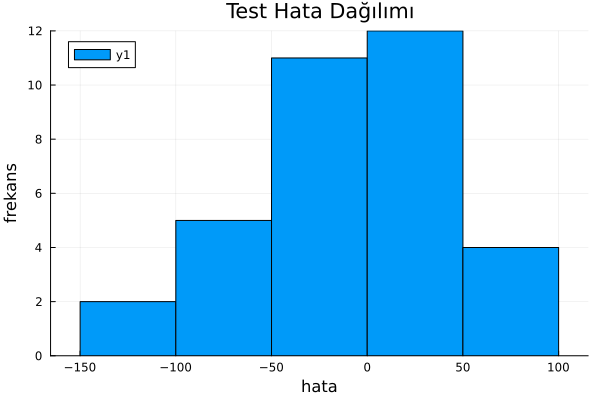

In [63]:
histogram(perf_test1.hata,title="Test Hata Dağılımı",ylabel="frekans",xlabel="hata",legend=true)

*Train Hatası Karşılaştırması*

In [64]:
println("Ortalama Mutlak Train Hatası: ",mean(abs.(perf_train1.hata)))
println("Ortalama Mutlak Yüzde Train Hatası: ",mape(perf_train1))
println("Kök Ortalama Kare Train Hatası: ", rmse(perf_train1))
println("Hata Kareleri Ortalaması Train Hatası: ", mean(perf_train1.hata_kare))

Ortalama Mutlak Train Hatası: 42.60537067823833
Ortalama Mutlak Yüzde Train Hatası: 0.17359914298080922
Kök Ortalama Kare Train Hatası: 58.60322249565695
Hata Kareleri Ortalaması Train Hatası: 3434.3376868754726


*Train Hata Dağılımı*

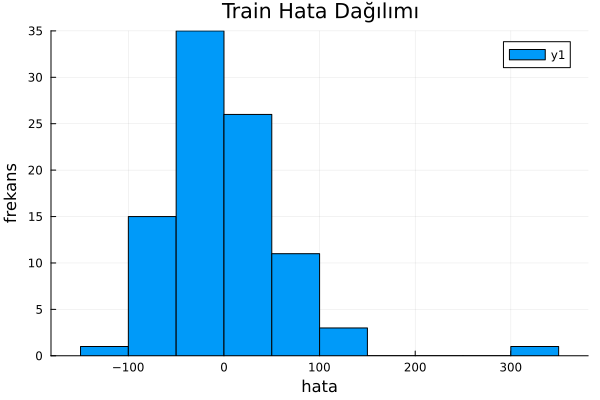

In [65]:
histogram(perf_train1.hata,title="Train Hata Dağılımı",ylabel="frekans",xlabel="hata",legend=true)

*Çapraz Doğrulama*

In [66]:
cross_validation(newdata,10,fm1)

LoadError: UndefVarError: cross_validation not defined

# Sonuç

- **MAE:**
  test: 42.99
  train: 42.6
- **MAPE:**
  test: 0.19
  train: 0.17
- **RMSE:**
  test: 51.33
  train: 58.6
- **MSE:**
  test: 2635.17
  train: 3434.33

sonuç olarak, modelin performansı çok iyi olmasada kabul edilebilir.

# **Sınıflandırma Modelleri**

In [67]:
using Pkg
Pkg.add("GLM")
Pkg.add("Lathe")
Pkg.add("ROCAnalysis")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("MLBase")

using DataFrames
using CSV
using GLM
using Lathe
using MLBase
using ROCAnalysis

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


In [68]:
describe(newdata)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Age,52.3492,28,53.0,75,0,Int64
2,Sex,,F,,M,0,String1
3,ChestPainType,,ASY,,TA,0,String3
4,RestingBP,131.897,100,130.0,200,0,Int64
5,Cholesterol,247.778,132,244.0,564,0,Int64
6,FastingBS,0.15873,0,0.0,1,0,Int64
7,RestingECG,,LVH,,ST,0,String7
8,MaxHR,140.968,87,140.0,202,0,Int64
9,ExerciseAngina,,N,,Y,0,String1


In [69]:
using Lathe.preprocess:TrainTestSplit
train,test=TrainTestSplit(newdata,.70)

(85×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  Resti ⋯
     │ Int64  String1  String3        Int64      Int64        Int64      Strin ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    56  M        ASY                  130          283          1  LVH   ⋯
   2 │    67  M        ASY                  160          286          0  LVH
   3 │    50  M        ASY                  144          349          0  LVH
   4 │    53  F        ASY                  138          234          0  LVH
   5 │    52  M        ASY                  130          298          0  Norma ⋯
   6 │    62  M        TA                   135          139          0  ST
   7 │    52  M        TA                   118          186          0  LVH
   8 │    69  M        NAP                  140          254          0  LVH
   9 │    51  M        ASY                  140          261          0  LVH   ⋯
  10 │    63  M        TA           

*Model Kurma*

In [70]:
fm=@formula(HeartDisease~Age+Sex+ChestPainType+RestingBP+Cholesterol+FastingBS+RestingECG+MaxHR+ExerciseAngina+Oldpeak+ST_Slope)
logit=glm(fm,train,Binomial(),LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

HeartDisease ~ 1 + Age + Sex + ChestPainType + RestingBP + Cholesterol + FastingBS + RestingECG + MaxHR + ExerciseAngina + Oldpeak + ST_Slope

Coefficients:
─────────────────────────────────────────────────────────────────────────────────────
                          Coef.  Std. Error      z  Pr(>|z|)    Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────────────
(Intercept)         -3.52979      6.49202    -0.54    0.5866  -16.2539      9.19433
Age                 -0.0578247    0.0609309  -0.95    0.3426   -0.177247    0.0615976
Sex: M               6.27343      2.34513     2.68    0.0075    1.67707    10.8698
ChestPainType: ATA  -3.00798      1.45333    -2.07    0.0385   -5.85646    -0.159504
ChestPainType: NAP  -4.1668

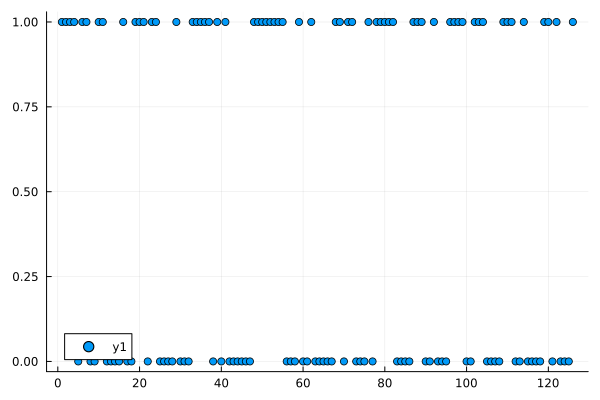

In [71]:
using Plots
scatter(newdata[!,:HeartDisease])

In [72]:
predictions=predict(logit,test)

41-element Vector{Union{Missing, Float64}}:
 0.9611045773058631
 0.9955968001534016
 0.8921310388434216
 0.5789608636399942
 0.08937427601574677
 0.027285488673134968
 0.05063208803362568
 0.999110073415957
 0.21147992710198696
 0.9961462453069412
 0.46044300644071073
 7.956734407993585e-5
 0.9998553528353655
 ⋮
 0.9379473082826283
 0.027760451101195273
 0.6037588844109553
 0.6312612197501054
 0.9725946257513612
 0.9999758540349085
 0.9985171490220935
 0.0003862587023612634
 0.04150126287407708
 0.10173240259112733
 0.00797834591973323
 0.999720081755621

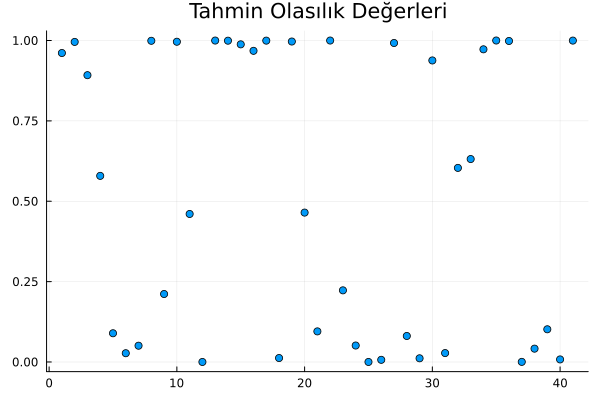

In [73]:
scatter(predictions, title="Tahmin Olasılık Değerleri",legend=false)

In [74]:
prediction_class=[if x<0.5 0 else 1 end for x in predictions]

41-element Vector{Int64}:
 1
 1
 1
 1
 0
 0
 0
 1
 0
 1
 0
 0
 1
 ⋮
 1
 0
 1
 1
 1
 1
 1
 0
 0
 0
 0
 1

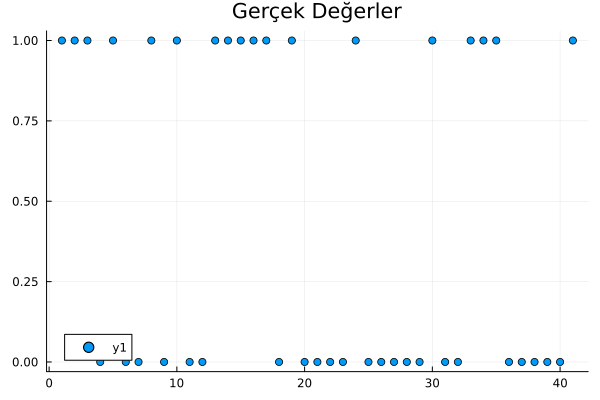

In [75]:
scatter(test[!,:HeartDisease], title="Gerçek Değerler")

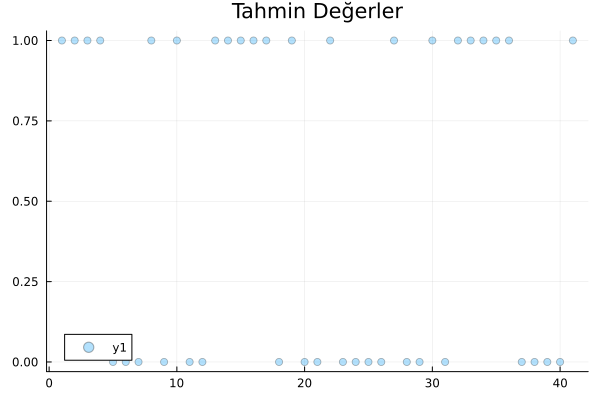

In [76]:
scatter(prediction_class, opacity=0.3, title="Tahmin Değerler")

In [77]:
prediction_newdata=DataFrame(y_actual=test.HeartDisease,prob_predicted=predictions,y_predicted=prediction_class)

,y_actual,prob_predicted,y_predicted
,Int64,Float64?,Int64
1,1,0.961105,1
2,1,0.995597,1
3,1,0.892131,1
4,0,0.578961,1
5,1,0.0893743,0
6,0,0.0272855,0
7,0,0.0506321,0
8,1,0.99911,1
9,0,0.21148,0


In [78]:
using MLBase
confusion_matrix=MLBase.roc(prediction_newdata.y_actual,prediction_newdata.y_predicted)

ROCNums{Int64}
  p = 18
  n = 23
  tp = 16
  tn = 18
  fp = 5
  fn = 2


In [79]:
accuracy(cm)=(cm.tp+cm.tn)/(cm.tp+cm.tn+cm.fp+cm.fn)

accuracy (generic function with 1 method)

In [80]:
specificity(cm)=cm.tn/(cm.tn+cm.fp)

specificity (generic function with 1 method)

In [81]:
precision(cm)=cm.tp/(cm.tp+cm.fp)

precision (generic function with 1 method)

In [82]:
recall(cm)=cm.tp/(cm.tp+cm.fn)

recall (generic function with 1 method)

In [83]:
F1score(cm)=2*cm.tp/(2*cm.tp+cm.fp+cm.fn)

F1score (generic function with 1 method)

*Analiz Sonucu*

In [84]:
println("Accuracy: ",accuracy(confusion_matrix))
println("Specificity: ",specificity(confusion_matrix))
println("Precision: ",precision(confusion_matrix))
println("Recall: ",recall(confusion_matrix))
println("F1Score: ",F1score(confusion_matrix))

Accuracy: 0.8292682926829268
Specificity: 0.782608695652174
Precision: 0.7619047619047619
Recall: 0.8888888888888888
F1Score: 0.8205128205128205


 # Sonuç
 - **Accuracy-Doğruluk:** modelin doğruluk oranı 0.83 çıkmıştır. doğruluk oranı yüksektir.
 - **Specificity-Özgüllük:** modelin negatif sınıfları tanımlama oranı 0.78 çıkmış olup modelin negatif sınıfları tanımlamada başarılıdır.
 - **Preciion-Hassasiyet:** modelin, pozitif olarak tahmin ettiği değerlerin gerçekte de pozitif olma oranı 0.76 çıkmış ve yüksektir.
 - **Recall-Duyarlılık:** modelin gerçek pozitif değerleri yakalama oranı 0.88'tir ve modelin pozitif örnekleri kaçırma eğiliminde olduğu söylenebilir.
 - **F1 Score:** modelin hassasiyet ve duyarlılık dengesi 0.82'tir. Modelin Sağlıkli bir dengeye sahip olduğu söylenebilir.

Sonuç olarak,modelin genel olarak performansının iyi olduğu söylenebilir. F1 skoruna bakacak olursak, model %82 oranında başarılı olduğu söylenebilir.

# **Karar Ağaçları**

In [85]:
using Pkg
Pkg.add("DecisionTree")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("MLBase")
Pkg.add("MLJ")

using DecisionTree
using CSV
using DataFrames
using MLBase
using MLJ

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


In [86]:
using Lathe.preprocess: TrainTestSplit
train,test=TrainTestSplit(newdata,.60)

(71×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  Resti ⋯
     │ Int64  String1  String3        Int64      Int64        Int64      Strin ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    40  F        ASY                  150          392          0  Norma ⋯
   2 │    67  M        ASY                  160          286          0  LVH
   3 │    50  M        ASY                  144          349          0  LVH
   4 │    53  F        ASY                  138          234          0  LVH
   5 │    52  M        ASY                  130          298          0  Norma ⋯
   6 │    62  M        TA                   135          139          0  ST
   7 │    51  M        ASY                  140          261          0  LVH
   8 │    39  M        ASY                  130          307          0  Norma
   9 │    63  M        TA                   145          233          1  LVH   ⋯
  10 │    44  M        ATA        

*feature selection (Train)*

In [87]:
features = Array(train[:,[:Cholesterol, :RestingBP, :MaxHR]])
labels = Array(train[:,:ChestPainType])
features = float.(features)
labels = string.(labels)

71-element Vector{String3}:
 "ASY"
 "ASY"
 "ASY"
 "ASY"
 "ASY"
 "TA"
 "ASY"
 "ASY"
 "TA"
 "ATA"
 "ATA"
 "ASY"
 "ASY"
 ⋮
 "ATA"
 "ASY"
 "ATA"
 "ATA"
 "ASY"
 "ASY"
 "ASY"
 "NAP"
 "NAP"
 "TA"
 "ATA"
 "ASY"

*feature selection (Test)*

In [88]:
features_test = Array(test[:,[:Cholesterol, :RestingBP, :MaxHR]])
labels_test = Array(test[:,:ChestPainType])
features_test = float.(features_test)
labels_test = string.(labels_test)

55-element Vector{String3}:
 "ASY"
 "ASY"
 "TA"
 "NAP"
 "ATA"
 "TA"
 "ATA"
 "ASY"
 "ASY"
 "ATA"
 "ATA"
 "ASY"
 "ATA"
 ⋮
 "NAP"
 "NAP"
 "ASY"
 "ATA"
 "ASY"
 "ASY"
 "ATA"
 "ASY"
 "NAP"
 "ATA"
 "TA"
 "ASY"

- 2.yol

In [89]:
using DecisionTree

model = build_tree(labels, features)

Decision Tree
Leaves: 34
Depth:  10

In [90]:
print_tree(model, 5)

Feature 3 < 123.0 ?
├─ Feature 3 < 96.5 ?
    ├─ Feature 2 < 145.0 ?
        ├─ NAP : 1/1
        └─ ASY : 1/1
    └─ Feature 1 < 308.0 ?
        ├─ ASY : 11/11
        └─ Feature 1 < 333.5 ?
            ├─ NAP : 1/1
            └─ ASY : 2/2
└─ Feature 1 < 190.0 ?
    ├─ Feature 2 < 132.5 ?
        ├─ Feature 2 < 119.0 ?
            ├─ NAP : 1/1
            └─ ATA : 3/3
        └─ TA : 3/3
    └─ Feature 3 < 163.0 ?
        ├─ Feature 1 < 292.0 ?
            ├─ Feature 1 < 226.0 ?
                ├─ 
                └─ 
            └─ ASY : 6/6
        └─ Feature 2 < 137.5 ?
            ├─ Feature 1 < 197.5 ?
                ├─ ASY : 1/1
                └─ 
            └─ Feature 1 < 275.0 ?
                ├─ ASY : 1/1
                └─ 


In [91]:
predictions = apply_tree(model, features_test)

55-element Vector{String3}:
 "ASY"
 "ASY"
 "NAP"
 "TA"
 "TA"
 "ATA"
 "ATA"
 "ASY"
 "TA"
 "NAP"
 "ASY"
 "NAP"
 "ATA"
 ⋮
 "NAP"
 "ASY"
 "NAP"
 "ASY"
 "ASY"
 "ASY"
 "ATA"
 "ASY"
 "NAP"
 "TA"
 "NAP"
 "ASY"

In [92]:
apply_tree_proba(model, [186,118,124], ["Cholesterol", "RestingBP", "MaxHR"])

LoadError: MethodError: no method matching apply_tree_proba(::Root{Float64, String3}, ::Vector{Int64}, ::Vector{String})
[0mClosest candidates are:
[0m  apply_tree_proba(::Root{S, T}, [91m::AbstractVector{S}[39m, ::Any) where {S, T} at /Users/selinyuksektepe/.julia/packages/DecisionTree/0Dw1P/src/classification/main.jl:311
[0m  apply_tree_proba([91m::Leaf{T}[39m, ::AbstractVector{S}, ::Any) where {S, T} at /Users/selinyuksektepe/.julia/packages/DecisionTree/0Dw1P/src/classification/main.jl:314
[0m  apply_tree_proba([91m::DecisionTree.Node{S, T}[39m, ::AbstractVector{S}, ::Any) where {S, T} at /Users/selinyuksektepe/.julia/packages/DecisionTree/0Dw1P/src/classification/main.jl:318
[0m  ...

In [93]:
n_folds=3
accuracy = nfoldCV_tree(labels_test, features_test, n_folds)


Fold 1
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 4  2  0  3
 1  3  0  0
 3  2  0  0
 0  0  0  0


Accuracy: 0.3888888888888889
Kappa:    0.11607142857142862

Fold 2
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 6  1  1  1
 2  1  2  1
 1  0  0  0
 1  1  0  0


Accuracy: 0.3888888888888889
Kappa:    0.0526315789473684

Fold 3
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 4  3  3  0
 0  2  2  0
 1  2  0  0
 1  0  0  0


Accuracy: 0.3333333333333333
Kappa:    0.022624434389140212

Mean Accuracy: 0.3703703703703704


LoadError: invalid redefinition of constant accuracy

In [94]:
modelp = prune_tree(model, 0.6)

Decision Tree
Leaves: 26
Depth:  10

In [95]:
print_tree(modelp, 6)

Feature 3 < 123.0 ?
├─ Feature 3 < 96.5 ?
    ├─ Feature 2 < 145.0 ?
        ├─ NAP : 1/1
        └─ ASY : 1/1
    └─ ASY : 13/14
└─ Feature 1 < 190.0 ?
    ├─ Feature 2 < 132.5 ?
        ├─ ATA : 3/4
        └─ TA : 3/3
    └─ Feature 3 < 163.0 ?
        ├─ Feature 1 < 292.0 ?
            ├─ Feature 1 < 226.0 ?
                ├─ Feature 2 < 133.0 ?
                    ├─ 
                    └─ ASY : 4/4
                └─ Feature 3 < 157.5 ?
                    ├─ 
                    └─ ASY : 3/3
            └─ ASY : 6/6
        └─ Feature 2 < 137.5 ?
            ├─ Feature 1 < 197.5 ?
                ├─ ASY : 1/1
                └─ Feature 3 < 179.5 ?
                    ├─ 
                    └─ ATA : 3/3
            └─ Feature 1 < 275.0 ?
                ├─ ASY : 1/1
                └─ Feature 3 < 171.0 ?
                    ├─ ASY : 1/1
                    └─ ATA : 1/1


In [96]:
preds1=apply_tree(modelp,features_test)
n_folds=3
accuracy1 = nfoldCV_tree(preds1, features_test, n_folds)


Fold 1
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 8  1  2  0
 1  0  0  2
 0  0  0  0
 0  3  0  1


Accuracy: 0.5
Kappa:    0.19402985074626863

Fold 2
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 9  0  1  0
 0  0  0  0
 3  1  0  0
 2  0  0  2


Accuracy: 0.6111111111111112
Kappa:    0.2674418604651164

Fold 3
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 5  0  1  1
 1  0  0  3
 2  3  1  1
 0  0  0  0


Accuracy: 0.3333333333333333
Kappa:    0.10743801652892558

Mean Accuracy: 0.48148148148148145


3-element Vector{Float64}:
 0.5
 0.6111111111111112
 0.3333333333333333

# Sonuç
- **Ortalama Doğruluk oranı:** 0.48
- Fold 1 Doğruluk oranı: 0.5
- Fold 2 Doğruluk oranı: 0.61
- Fold 3 Doğruluk oranı: 0.33

Modelin genel performansı için ortalma doğruluk oranına bakılmaktadır. modelin oranı %48'tir . Modelin performansının ortalama olduğu söylenebilir.

# *Random Forest*

In [97]:
n_subfeatures=2;n_trees=10;partial_sampling=0.7;max_depth=-1;min_samples_leaf=5;min_samples_split=4;min_purity_increase=2.0
forest=build_forest(labels,features,n_subfeatures,n_trees,partial_sampling,min_samples_leaf,min_samples_split,min_purity_increase,rng=3)

Ensemble of Decision Trees
Trees:      10
Avg Leaves: 8.5
Avg Depth:  4.3

In [98]:
accuracy=nfoldCV_forest(labels_test,features_test,3)


Fold 1
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 10  0  0  0
  2  1  0  0
  2  2  0  0
  1  0  0  0


Accuracy: 0.6111111111111112
Kappa:    0.23636363636363641

Fold 2
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 6  4  1  0
 0  1  3  0
 2  0  0  0
 0  1  0  0


Accuracy: 0.3888888888888889
Kappa:    0.029411764705882394

Fold 3
Classes:  String3["ASY", "ATA", "NAP", "TA"]
Matrix:   

4×4 Matrix{Int64}:
 4  2  0  0
 5  2  0  0
 2  2  0  0
 1  0  0  0


Accuracy: 0.3333333333333333
Kappa:    -0.028571428571428612

Mean Accuracy: 0.4444444444444444


LoadError: invalid redefinition of constant accuracy

# Sonuç

**Ortalama doğruluk oranı:** Ortalama doğruluk olanı %44 bulunmuştur. Modelin performansının ortalama olduğu söylenebilir.

# **K-En Yakın Komşuluk Algoritması**

In [99]:
using Pkg
Pkg.add("DecisionTree")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("MLBase")
Pkg.add("NearestNeighbors")
Pkg.add("DataStructures")

using DataStructures
using NearestNeighbors
using MLBase
using DecisionTree
using CSV
using DataFrames

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


In [100]:
describe(newdata)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Age,52.3492,28,53.0,75,0,Int64
2,Sex,,F,,M,0,String1
3,ChestPainType,,ASY,,TA,0,String3
4,RestingBP,131.897,100,130.0,200,0,Int64
5,Cholesterol,247.778,132,244.0,564,0,Int64
6,FastingBS,0.15873,0,0.0,1,0,Int64
7,RestingECG,,LVH,,ST,0,String7
8,MaxHR,140.968,87,140.0,202,0,Int64
9,ExerciseAngina,,N,,Y,0,String1


In [101]:
using Lathe.preprocess: TrainTestSplit
train,test=TrainTestSplit(newdata,.60)

(74×12 DataFrame
 Row │ Age    Sex      ChestPainType  RestingBP  Cholesterol  FastingBS  Resti ⋯
     │ Int64  String1  String3        Int64      Int64        Int64      Strin ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    40  F        ASY                  150          392          0  Norma ⋯
   2 │    56  M        ASY                  130          283          1  LVH
   3 │    53  F        ASY                  138          234          0  LVH
   4 │    52  M        TA                   118          186          0  LVH
   5 │    69  M        NAP                  140          254          0  LVH   ⋯
   6 │    35  M        ATA                  110          257          0  Norma
   7 │    39  M        ASY                  130          307          0  Norma
   8 │    63  M        TA                   145          233          1  LVH
   9 │    44  M        ATA                  120          263          0  Norma ⋯
  10 │    67  M        TA      

**feature selection (Train)**

In [102]:
features = Array(train[:,[:Age, :RestingBP, :Cholesterol]])
labels = Array(train[:,:HeartDisease])
features = float.(features)
labels1=string.(labels)

74-element Vector{String}:
 "1"
 "1"
 "0"
 "0"
 "1"
 "1"
 "0"
 "0"
 "0"
 "1"
 "0"
 "0"
 "1"
 ⋮
 "1"
 "1"
 "0"
 "1"
 "0"
 "0"
 "0"
 "1"
 "1"
 "0"
 "0"
 "0"

**feature_selection (Test)**

In [103]:
features_test = Array(test[:,[:Age, :RestingBP, :Cholesterol]])
labels_test = Array(test[:,:HeartDisease])
features_test = float.(features_test)
labels_test1=string.(labels_test)

52-element Vector{String}:
 "1"
 "1"
 "1"
 "1"
 "0"
 "0"
 "0"
 "1"
 "1"
 "1"
 "1"
 "0"
 "1"
 ⋮
 "1"
 "0"
 "0"
 "0"
 "0"
 "1"
 "1"
 "0"
 "0"
 "1"
 "0"
 "1"

In [104]:
kdtree=KDTree(features')

KDTree{StaticArraysCore.SVector{3, Float64}, Euclidean, Float64, StaticArraysCore.SVector{3, Float64}}
  Number of points: 74
  Dimensions: 3
  Metric: Euclidean(0.0)
  Reordered: true

Her bir veri noktasına 5 en yakın komşu bulmak için:

In [105]:
idxs,dists=knn(kdtree, features',5, true)

([[1, 34, 59, 25, 7], [2, 38, 72, 71, 41], [3, 60, 52, 35, 8], [4, 32, 56, 23, 47], [5, 51, 24, 10, 73], [6, 46, 9, 45, 64], [7, 19, 36, 65, 57], [8, 20, 3, 35, 52], [9, 46, 30, 6, 72], [10, 71, 53, 5, 38]  …  [65, 27, 36, 66, 41], [66, 65, 41, 27, 36], [67, 32, 56, 14, 49], [68, 58, 71, 72, 24], [69, 21, 47, 26, 23], [70, 18, 12, 74, 33], [71, 38, 2, 72, 58], [72, 38, 2, 71, 9], [73, 8, 51, 5, 20], [74, 18, 26, 70, 12]], [[0.0, 54.16641025580336, 55.21775076911409, 63.93746945258312, 87.3269717784832], [0.0, 7.0, 11.357816691600547, 12.041594578792296, 14.866068747318506], [0.0, 9.16515138991168, 9.219544457292887, 9.273618495495704, 12.24744871391589], [0.0, 14.422205101855956, 15.329709716755891, 15.620499351813308, 15.7797338380595], [0.0, 4.47213595499958, 11.661903789690601, 16.24807680927192, 18.384776310850235], [0.0, 12.206555615733702, 14.730919862656235, 15.588457268119896, 23.345235059857504], [0.0, 4.58257569495584, 11.832159566199232, 16.09347693943108, 17.320508075688775

In [106]:
idxs

74-element Vector{Vector{Int64}}:
 [1, 34, 59, 25, 7]
 [2, 38, 72, 71, 41]
 [3, 60, 52, 35, 8]
 [4, 32, 56, 23, 47]
 [5, 51, 24, 10, 73]
 [6, 46, 9, 45, 64]
 [7, 19, 36, 65, 57]
 [8, 20, 3, 35, 52]
 [9, 46, 30, 6, 72]
 [10, 71, 53, 5, 38]
 [11, 63, 49, 43, 69]
 [12, 17, 70, 69, 11]
 [13, 53, 73, 10, 5]
 ⋮
 [63, 11, 49, 14, 43]
 [64, 46, 9, 57, 72]
 [65, 27, 36, 66, 41]
 [66, 65, 41, 27, 36]
 [67, 32, 56, 14, 49]
 [68, 58, 71, 72, 24]
 [69, 21, 47, 26, 23]
 [70, 18, 12, 74, 33]
 [71, 38, 2, 72, 58]
 [72, 38, 2, 71, 9]
 [73, 8, 51, 5, 20]
 [74, 18, 26, 70, 12]

In [107]:
dists

74-element Vector{Vector{Float64}}:
 [0.0, 54.16641025580336, 55.21775076911409, 63.93746945258312, 87.3269717784832]
 [0.0, 7.0, 11.357816691600547, 12.041594578792296, 14.866068747318506]
 [0.0, 9.16515138991168, 9.219544457292887, 9.273618495495704, 12.24744871391589]
 [0.0, 14.422205101855956, 15.329709716755891, 15.620499351813308, 15.7797338380595]
 [0.0, 4.47213595499958, 11.661903789690601, 16.24807680927192, 18.384776310850235]
 [0.0, 12.206555615733702, 14.730919862656235, 15.588457268119896, 23.345235059857504]
 [0.0, 4.58257569495584, 11.832159566199232, 16.09347693943108, 17.320508075688775]
 [0.0, 10.723805294763608, 12.24744871391589, 14.491376746189438, 15.0]
 [0.0, 10.099504938362077, 13.856406460551018, 14.730919862656235, 15.0]
 [0.0, 13.152946437965905, 14.696938456699069, 16.24807680927192, 17.349351572897472]
 [0.0, 7.681145747868608, 10.198039027185569, 16.30950643030009, 16.792855623746664]
 [0.0, 10.392304845413264, 15.0996688705415, 18.138357147217054, 18.7882

In [108]:
c=labels[hcat(idxs...)]

5×74 Matrix{Int64}:
 1  1  0  0  1  1  0  0  0  1  0  0  1  …  1  1  0  1  0  0  0  1  1  0  0  0
 1  0  1  1  0  1  0  0  1  1  1  1  1     0  1  0  0  1  0  1  0  0  0  0  0
 0  0  0  0  1  0  0  0  1  1  0  1  0     0  0  0  1  0  1  1  0  1  1  0  0
 1  1  0  1  1  0  0  0  1  1  0  0  1     0  0  1  0  0  0  0  0  0  1  1  1
 0  1  0  1  0  1  0  0  0  0  0  0  1     0  0  1  0  0  1  1  1  0  0  0  0

In [109]:
hcat(idxs...)

5×74 Matrix{Int64}:
  1   2   3   4   5   6   7   8   9  …  66  67  68  69  70  71  72  73  74
 34  38  60  32  51  46  19  20  46     65  32  58  21  18  38  38   8  18
 59  72  52  56  24   9  36   3  30     41  56  71  47  12   2   2  51  26
 25  71  35  23  10  45  65  35   6     27  14  72  26  74  72  71   5  70
  7  41   8  47  73  64  57  52  72     36  49  24  23  33  58   9  20  12

In [110]:
possible_labels=map(i->counter(c[:,i]),1:size(c,2))

74-element Vector{Accumulator{Int64, Int64}}:
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 4, 1 => 1)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 5)
 Accumulator(0 => 5)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 1, 1 => 4)
 Accumulator(0 => 4, 1 => 1)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 1, 1 => 4)
 ⋮
 Accumulator(0 => 4, 1 => 1)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 4, 1 => 1)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 2, 1 => 3)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 3, 1 => 2)
 Accumulator(0 => 4, 1 => 1)
 Accumulator(0 => 4, 1 => 1)

In [111]:
using DataFrames
predictions_NN=map(i->parse(Int,string(argmax(DataFrame(possible_labels[i])[1,:]))),1:size(c,2))

LoadError: ArgumentError: All column names must be either Symbols or strings (mixing is not allowed)

In [112]:
using MLBase
confusion_matrix=MLBase.roc(Array(labels),Array(predictions_NN))

LoadError: UndefVarError: predictions_NN not defined

# Sonuç

- p:
- n:
- tp:
- tn:
- fp:
- fn:

- **Accuracy-Doğruluk:** (tp+tn)/(p+n)=
- **Precision-Kesinlik:** tp/(tp+fp)=
- **Recall-Duyarlılık:** tp/p=

Modelin başarılı bir performans sergileyip sergilemediğine bakmak için Doğruluk oranına bakılır.

# **Kümeleme**

In [113]:
using Pkg
Pkg.add("Clustering")
Pkg.add("Distances")
Pkg.add("Plots")
Pkg.add("CSV")

using CSV
using Clustering
using Distances
using Plots

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


In [114]:
describe(newdata)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Age,52.3492,28,53.0,75,0,Int64
2,Sex,,F,,M,0,String1
3,ChestPainType,,ASY,,TA,0,String3
4,RestingBP,131.897,100,130.0,200,0,Int64
5,Cholesterol,247.778,132,244.0,564,0,Int64
6,FastingBS,0.15873,0,0.0,1,0,Int64
7,RestingECG,,LVH,,ST,0,String7
8,MaxHR,140.968,87,140.0,202,0,Int64
9,ExerciseAngina,,N,,Y,0,String1


In [115]:
names(newdata)

12-element Vector{String}:
 "Age"
 "Sex"
 "ChestPainType"
 "RestingBP"
 "Cholesterol"
 "FastingBS"
 "RestingECG"
 "MaxHR"
 "ExerciseAngina"
 "Oldpeak"
 "ST_Slope"
 "HeartDisease"

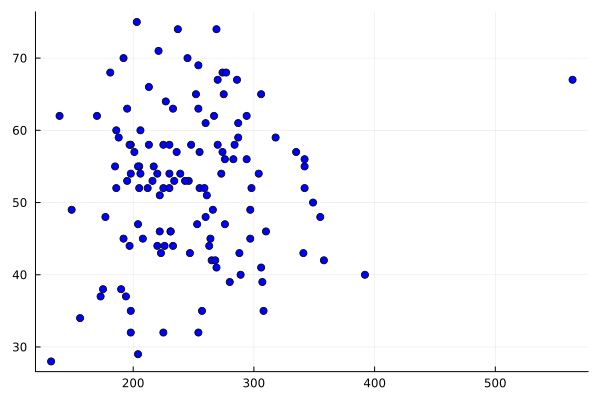

In [116]:
scatter(newdata.Cholesterol, newdata.Age,color=:blue, legend=false)

In [117]:
features = collect(Matrix(newdata[:, 5:12])');
result = kmeans(features,4 , display=:iter)

LoadError: MethodError: no method matching adjoint(::String7)
[0mClosest candidates are:
[0m  adjoint([91m::AbstractFFTs.ScaledPlan[39m) at /Users/selinyuksektepe/.julia/packages/AbstractFFTs/4iQz5/src/definitions.jl:675
[0m  adjoint([91m::LinearAlgebra.UpperTriangular[39m) at /Users/julia/buildbot/worker/package_macos64/build/usr/share/julia/stdlib/v1.6/LinearAlgebra/src/triangular.jl:397
[0m  adjoint([91m::LinearAlgebra.Bidiagonal{var"#s814", V} where {var"#s814"<:Real, V<:AbstractVector{var"#s814"}}[39m) at /Users/julia/buildbot/worker/package_macos64/build/usr/share/julia/stdlib/v1.6/LinearAlgebra/src/bidiag.jl:248
[0m  ...

In [118]:
result.centers

LoadError: UndefVarError: result not defined

In [119]:
result.counts

LoadError: UndefVarError: result not defined

In [120]:
result.assignments

LoadError: UndefVarError: result not defined

In [121]:
scatter(newdata.Cholesterol, newdata.Age, marker_z=result.assignments,
        color=:lightrainbow, legend=false)

LoadError: UndefVarError: result not defined

In [122]:
scatter(newdata.RestingBP, newdata.MaxHR, marker_z=result.assignments,
        color=:lightrainbow, legend=false)

LoadError: UndefVarError: result not defined

In [123]:
features = collect(Matrix(newdata[:, 5:12])'); 
result = kmeans(features, 3,display=:iter)

LoadError: MethodError: no method matching adjoint(::String7)
[0mClosest candidates are:
[0m  adjoint([91m::AbstractFFTs.ScaledPlan[39m) at /Users/selinyuksektepe/.julia/packages/AbstractFFTs/4iQz5/src/definitions.jl:675
[0m  adjoint([91m::LinearAlgebra.UpperTriangular[39m) at /Users/julia/buildbot/worker/package_macos64/build/usr/share/julia/stdlib/v1.6/LinearAlgebra/src/triangular.jl:397
[0m  adjoint([91m::LinearAlgebra.Bidiagonal{var"#s814", V} where {var"#s814"<:Real, V<:AbstractVector{var"#s814"}}[39m) at /Users/julia/buildbot/worker/package_macos64/build/usr/share/julia/stdlib/v1.6/LinearAlgebra/src/bidiag.jl:248
[0m  ...

In [124]:
scatter(newdata.Cholesterol,newdata.Age, marker_z=result.assignments,
        color=:lightrainbow, legend=false)

LoadError: UndefVarError: result not defined

**K-Medoids Kümeleme**

In [125]:
Pkg.add("Distances")
using Distances

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.6/Project.toml`
  No Changes to `~/.julia/environments/v1.6/Manifest.toml`


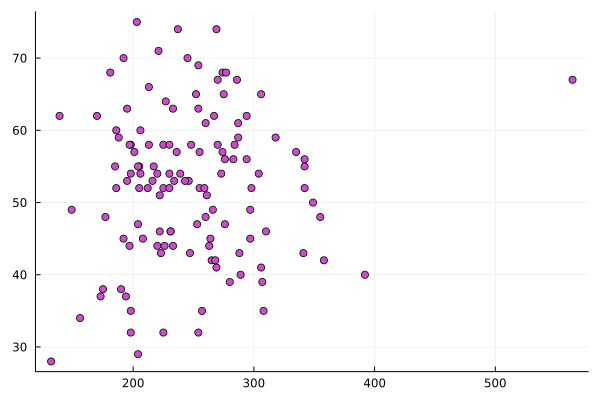

In [126]:
scatter(newdata.Cholesterol, newdata.Age,color=:lightrainbow, legend=false)

In [127]:
c=Matrix(features)

74×3 Matrix{Float64}:
 40.0  150.0  392.0
 56.0  130.0  283.0
 53.0  138.0  234.0
 52.0  118.0  186.0
 69.0  140.0  254.0
 35.0  110.0  257.0
 39.0  130.0  307.0
 63.0  145.0  233.0
 44.0  120.0  263.0
 67.0  142.0  270.0
 52.0  128.0  205.0
 44.0  120.0  220.0
 68.0  180.0  274.0
  ⋮           
 55.0  135.0  204.0
 39.0  110.0  280.0
 54.0  135.0  304.0
 65.0  140.0  306.0
 68.0  139.0  181.0
 74.0  120.0  269.0
 47.0  112.0  204.0
 52.0  112.0  230.0
 65.0  130.0  275.0
 54.0  125.0  273.0
 70.0  156.0  245.0
 43.0  100.0  223.0

In [128]:
D=pairwise(Euclidean(),c,c,dims=2)

3×3 Matrix{Float64}:
    0.0     694.599  1749.64
  694.599     0.0    1136.54
 1749.64   1136.54      0.0

In [129]:
C=kmediods(D,3,display=:iter)

LoadError: UndefVarError: kmediods not defined

In [130]:
K=kmedoids(D,3 , display=:iter)

  Iters               objv        objv-change
-----------------------------------------------------
      0       0.000000e+00
      1       0.000000e+00       0.000000e+00
K-medoids converged with 1 iterations (objv = 0.0)


KmedoidsResult{Float64}([1, 3, 2], [1, 3, 2], [0.0, 0.0, 0.0], [1, 1, 1], 0.0, 1, true)

In [131]:
K.assignments

3-element Vector{Int64}:
 1
 3
 2

In [132]:
scatter(newdata.Cholesterol, newdata.Age, marker_z=K.assignments,color=:lightrainbow, legend=false)

BoundsError: BoundsError: attempt to access 3-element Vector{Int64} at index [4]

**Dbscan**

In [133]:
dnewdata=pairwise(Euclidean(),features, dims=2)

3×3 Matrix{Float64}:
    0.0     694.599  1749.64
  694.599     0.0    1136.54
 1749.64   1136.54      0.0

In [134]:
L=dbscan(dnewdata, 1000, 10)

DbscanResult(DbscanCluster[], Int64[], Int64[], [0, 0, 0])

In [135]:
@show length(unique(L.assignments))

length(unique(L.assignments)) = 1


1

In [136]:
scatter(newdata.Cholesterol, newdata.Age,color=:lightrainbow,  marker_z=L.assignments,legend=false)

BoundsError: BoundsError: attempt to access 3-element Vector{Int64} at index [4]